Discente: Guilherme da Silva Ferraz.


# Análise do Dataset Sobre Evasão na UFMT

Este notebook realiza análises e visualizações utilizando o dataset **evasao_ufmt**.
Nosso roteiro:
1. **Compreensão Inicial dos Dados**
   - Carregar e visualizar o dataset
   - Resumo estatístico

2. **Análise Univariada**
   - Distribuições das variáveis numéricas
   - Boxplots

3. **Análise Bivariada**
   - Gráficos de dispersão (Scatter plots)
   - Pairplots

4. **Análise Multivariada**
   - Gráficos tridimensionais
   - Heatmap de correlação

5. **Conclusões e Insights**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import openpyxl as px
import numpy as np

# 1. Compreensão Inicial dos Dados


## Carregar o Dataset e Visualizar os Dados

In [2]:
data_ufmt = pd.read_excel('evasao.xlsx')

#### Entendimento do conjunto de dados

***Tamanho do Conjunto de Dados***

In [3]:
data_ufmt.shape

(11555, 15)

***Nome das Colunas***

In [4]:
data_ufmt.columns

Index(['campus', 'curso', 'sexo', 'dataNascimento', 'estadoCivil',
       'ocorrenciaDescricao', 'periodo', 'endereco', 'municipio', 'bairro',
       'cep', 'uf', 'anoNascimento', 'anoIngresso', 'anoEvasao'],
      dtype='object')

***Tipo de Variáveis***

In [5]:
data_ufmt.dtypes

campus                  object
curso                   object
sexo                    object
dataNascimento          object
estadoCivil             object
ocorrenciaDescricao     object
periodo                  int64
endereco                object
municipio               object
bairro                  object
cep                     object
uf                      object
anoNascimento          float64
anoIngresso            float64
anoEvasao                int64
dtype: object

***  
***
**Descrição das Variáveis**   
*** 
* campus - Campus Universitário
* curso - Curso de Graduação
* sexo - Sexo (Masculino ou Feminino)
* dataNascimento - Data de Nascimento
* estadoCivil -Estado Civil
* ocorrenciaDescricao - Descrição da Ocorrência
* periodo - Período (Semestre Letivo)
* endereco - Endereço
* municipio - Município
* bairro - Bairro
* cep - CEP (Código de Endereçamento Postal)
* uf - Unidade Federativa
* anoNascimento - Ano de Nascimento do Estudante
* anoIngresso - Ano de Ingresso na UFMT
* anoEvasao - Ano da Evasão
***  
***


**Exibição das 5 primeiras linhas do conjunto de dados**

In [6]:
data_ufmt.head()

,campus,curso,sexo,dataNascimento,estadoCivil,ocorrenciaDescricao,periodo,endereco,municipio,bairro,cep,uf,anoNascimento,anoIngresso,anoEvasao
0,CAMPUS CUIABÁ,ENGENHARIA CIVIL - SERIADO,M,1987-04-23 00:00:00.000,Solteiro(a),EXCLUSAO POR DESISTENCIA,20201,RUA CURSINO DO AMARANTE ...,CUIABA,QUILOMBO,78045070,MT,1987.0,2008.0,2020
1,CAMPUS CUIABÁ,BACHARELADO EM CIÊNCIAS SOCIAIS,M,1992-04-16 00:00:00.000,Solteiro(a),EXCLUSAO POR DESISTENCIA,20201,"Rua A, n250",CUIABA,Bairro Residencial Paiaguas,78048258,MT,1992.0,2010.0,2020
2,CAMPUS CUIABÁ,ENGENHARIA SANITARIA E AMBIENTAL - SERIADO SEM,F,1990-10-10 00:00:00.000,Solteiro(a),EXCLUSAO POR DESISTENCIA,20201,RUA AMÂNCIO PEDROSO DE JESUS ...,CUIABA,CARUMBÉ,78050660,MT,1990.0,2009.0,2020
3,CAMPUS CUIABÁ,GEOLOGIA - SERIADO,M,1982-09-30 00:00:00.000,Solteiro(a),EXCLUSAO POR DESISTENCIA,20201,TRAVESSA AGUA CLARA - 119,AQUIDAUANA,COHAB NOVA,78025433,MS,1982.0,2010.0,2020
4,CAMPUS CUIABÁ,DIREITO - SERIADO MATUTINO,F,1992-01-10 00:00:00.000,Solteiro(a),EXCLUSAO POR DESISTENCIA,20201,"RUA I, N 91, CS 03, RES GOLDEN VILLE",CUIABA,ALVORADA,78048487,MT,1992.0,2010.0,2020


**Exibição das 5 últimas linhas do conjunto de dados**

In [7]:
data_ufmt.tail()

,campus,curso,sexo,dataNascimento,estadoCivil,ocorrenciaDescricao,periodo,endereco,municipio,bairro,cep,uf,anoNascimento,anoIngresso,anoEvasao
11550,CAMPUS SINOP,MEDICINA VETERINÁRIA - BACHARELADO,F,2005-09-30 00:00:00.000,Solteiro(a),EXCLUSAO CONFORME EDITAL SISU - PELA INSTITUIÇÃO,20241,"Avenida Curuá-Una, 7055",SANTAREM,Jutaí,68045000,PA,2005.0,2024.0,2024
11551,CAMPUS SINOP,ZOOTECNIA - BACHARELADO,F,2002-05-15 00:00:00.000,Solteiro(a),EXCLUSAO POR DESISTENCIA,20241,"Rua Vinte e Quatro, 174",BETIM,Capelinha,32678270,MG,2002.0,2024.0,2024
11552,CAMPUS SINOP,ENGENHARIA AGRÍCOLA E AMBIENTAL BACHARELADO,F,2003-03-28 00:00:00.000,Solteiro(a),EXCLUSAO CONFORME EDITAL SISU - PELA INSTITUIÇÃO,20241,"Rua G-1, 367",CUIABA,Residencial Nova Canaã,78052860,MT,2003.0,2024.0,2024
11553,CAMPUS SINOP,QUÍMICA - BACHARELADO,M,1980-11-01 00:00:00.000,Solteiro(a),EXCLUSAO CONFORME EDITAL SISU - PELA INSTITUIÇÃO,20241,"Rua Ary Barroso, 218",SINOP,Aquarela Brasil Residencial,78556554,MT,1980.0,2024.0,2024
11554,CAMPUS VÁRZEA GRANDE,ENGENHARIA DE TRANSPORTES,M,2005-10-12 00:00:00.000,Solteiro(a),EXCLUSAO CONFORME EDITAL SISU - PELA INSTITUIÇÃO,20241,"Rua das Aroeiras, 31",CUIABA,Novo Mundo,78149496,MT,2005.0,2024.0,2024


***Valores ausentes (missing values)***

In [8]:
data_ufmt.isnull().sum() # Mostra a quantidade de valores ausentes por coluna

campus                  0
curso                   0
sexo                    0
dataNascimento          1
estadoCivil             0
ocorrenciaDescricao     0
periodo                 0
endereco                0
municipio               5
bairro                  0
cep                    36
uf                      5
anoNascimento           1
anoIngresso             3
anoEvasao               0
dtype: int64

**Tratando valores ausentes**

***Excluindo linhas com valores ausentes na coluna dataNascimento e anoNascimento***

In [9]:
# Exclui linhas com valores ausentes nessas colunas, já que são poucos e não vão atrapalhar a análise
data_ufmt = data_ufmt.dropna(subset=['dataNascimento', 'anoNascimento', 'anoIngresso'])

In [10]:
data_ufmt.isnull().sum()

campus                  0
curso                   0
sexo                    0
dataNascimento          0
estadoCivil             0
ocorrenciaDescricao     0
periodo                 0
endereco                0
municipio               5
bairro                  0
cep                    36
uf                      5
anoNascimento           0
anoIngresso             0
anoEvasao               0
dtype: int64

In [11]:
data_ufmt.fillna(0, inplace=True)
data_ufmt.isnull().sum()

campus                 0
curso                  0
sexo                   0
dataNascimento         0
estadoCivil            0
ocorrenciaDescricao    0
periodo                0
endereco               0
municipio              0
bairro                 0
cep                    0
uf                     0
anoNascimento          0
anoIngresso            0
anoEvasao              0
dtype: int64

***Valores Únicos na coluna 'campus'***

In [12]:
data_ufmt['campus'].unique()

array(['CAMPUS CUIABÁ', 'CAMPUS ARAGUAIA', 'CAMPUS SINOP',
       'CAMPUS VÁRZEA GRANDE'], dtype=object)

***Quantidade de Valores Únicos por Coluna***

In [13]:
data_ufmt.nunique()

campus                     4
curso                    148
sexo                       2
dataNascimento          6064
estadoCivil                3
ocorrenciaDescricao       19
periodo                    9
endereco               10883
municipio                633
bairro                  3725
cep                     5166
uf                        28
anoNascimento             65
anoIngresso               24
anoEvasao                  5
dtype: int64

### Ajustar o tipo das variáveis  

**Converter variáveis tipo ponto flutuante (float64) para tipo inteiro (int64)**

In [14]:
data_ufmt['anoIngresso'] = data_ufmt['anoIngresso'].astype('int64')
data_ufmt['anoNascimento'] = data_ufmt['anoNascimento'].astype('int64')

**Converter variáveis tipo object para tipo Date**

In [15]:
data_ufmt['dataNascimento'] = pd.to_datetime(data_ufmt['dataNascimento'], errors='coerce')
data_ufmt['dataNascimento'].dtypes

dtype('<M8[ns]')

**Converter variáveis categóricas (strings) para tipo category**

In [16]:
for col in data_ufmt.select_dtypes(include=['object']).columns:
    data_ufmt[col] = data_ufmt[col].astype('category')
data_ufmt.dtypes

campus                       category
curso                        category
sexo                         category
dataNascimento         datetime64[ns]
estadoCivil                  category
ocorrenciaDescricao          category
periodo                         int64
endereco                     category
municipio                    category
bairro                       category
cep                          category
uf                           category
anoNascimento                   int64
anoIngresso                     int64
anoEvasao                       int64
dtype: object

## Estatísticas Descritivas

***1. Medidas de Tendência Central***

In [17]:
dt_ufmt = data_ufmt.select_dtypes(include='number')  # Calcula a média apenas para colunas numéricas
for column in dt_ufmt.columns:
    print(f"Resultados de {column}:")
    print(f"  Média: {int (dt_ufmt[column].mean())}")
    print(f"  Mediana: {int (dt_ufmt[column].median())}")
    print(f"  Moda: {dt_ufmt[column].mode()[0]}")
    print()


Resultados de periodo:
  Média: 20224
  Mediana: 20231
  Moda: 20231

Resultados de anoNascimento:
  Média: 1994
  Mediana: 1997
  Moda: 2002

Resultados de anoIngresso:
  Média: 2018
  Mediana: 2019
  Moda: 2017

Resultados de anoEvasao:
  Média: 2022
  Mediana: 2023
  Moda: 2023



***2. Medidas de Disperção***

In [18]:
dt_ufmt = data_ufmt.select_dtypes(include='number')  # Calcula a média apenas para colunas numéricas
for column in dt_ufmt.columns:
    print(f"Resultados de {column}:")
    print(f"  Desvio Padrão: {dt_ufmt[column].std().round(2)}")
    print(f"  Variância: {dt_ufmt[column].var().round(2)}")
    print(f"  Amplitude: {dt_ufmt[column].max() - dt_ufmt[column].min()}")
    print()


Resultados de periodo:
  Desvio Padrão: 10.46
  Variância: 109.36
  Amplitude: 40

Resultados de anoNascimento:
  Desvio Padrão: 8.54
  Variância: 72.98
  Amplitude: 79

Resultados de anoIngresso:
  Desvio Padrão: 3.2
  Variância: 10.21
  Amplitude: 28

Resultados de anoEvasao:
  Desvio Padrão: 1.06
  Variância: 1.11
  Amplitude: 4



***3. Medidas de Forma***

In [19]:
dt_ufmt = data_ufmt.select_dtypes(include='number')  # Calcula a média apenas para colunas numéricas
for column in dt_ufmt.columns:
    print(f"Resultados de {column}:")
    print(f"  Assimetria (metade esquerda é uma imagem refletida da metade direita): {data_ufmt[column].skew().round(5)}")
    print(f"  Curtose (distribuição mais achatada que gaussiana): {data_ufmt[column].kurt().round(5)}")
    print()


Resultados de periodo:
  Assimetria (metade esquerda é uma imagem refletida da metade direita): -0.91935
  Curtose (distribuição mais achatada que gaussiana): -0.00252

Resultados de anoNascimento:
  Assimetria (metade esquerda é uma imagem refletida da metade direita): -1.63715
  Curtose (distribuição mais achatada que gaussiana): 3.14528

Resultados de anoIngresso:
  Assimetria (metade esquerda é uma imagem refletida da metade direita): -0.39837
  Curtose (distribuição mais achatada que gaussiana): -0.22273

Resultados de anoEvasao:
  Assimetria (metade esquerda é uma imagem refletida da metade direita): -0.90838
  Curtose (distribuição mais achatada que gaussiana): -0.03834



### Outliers

In [20]:
# Seleciona apenas colunas numéricas
dt_ufmt = data_ufmt.select_dtypes(include='number')

for col in dt_ufmt.columns:
    # Quartis e IQR
    Q1 = dt_ufmt[col].quantile(0.25)
    Q3 = dt_ufmt[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Identificação de outliers
    outliers = dt_ufmt[(dt_ufmt[col] < limite_inferior) | (dt_ufmt[col] > limite_superior)]

    # Exibindo resultados
    print(f"Coluna: {col}")
    print(f"  Limite Inferior: {limite_inferior}")
    print(f"  Limite Superior: {limite_superior}")
    print(f"  Número de Outliers: {len(outliers)}")
    print(f"  Assimetria (skew): {data_ufmt[col].skew().round(5)}")
    print(f"  Curtose (kurtosis): {data_ufmt[col].kurt().round(5)}")
    print()


Coluna: periodo
  Limite Inferior: 20206.0
  Limite Superior: 20246.0
  Número de Outliers: 1013
  Assimetria (skew): -0.91935
  Curtose (kurtosis): -0.00252

Coluna: anoNascimento
  Limite Inferior: 1978.5
  Limite Superior: 2014.5
  Número de Outliers: 703
  Assimetria (skew): -1.63715
  Curtose (kurtosis): 3.14528

Coluna: anoIngresso
  Limite Inferior: 2008.5
  Limite Superior: 2028.5
  Número de Outliers: 28
  Assimetria (skew): -0.39837
  Curtose (kurtosis): -0.22273

Coluna: anoEvasao
  Limite Inferior: 2020.5
  Limite Superior: 2024.5
  Número de Outliers: 1013
  Assimetria (skew): -0.90838
  Curtose (kurtosis): -0.03834



### Análise de Correlação  
A **Correlação de Pearson** mede a dependência linear entre duas variáveis ​​X e Y. O coeficiente resultante é um valor entre -1 e 1. Onde:  

**a.** 1: Correlação linear positiva perfeita. indicando que quando uma variável aumenta, a outra também aumenta na mesma proporção.  
**b.** 0: Sem correlação linear, as duas variáveis ​​provavelmente não afetam uma à outra.  
**c.** -1: Correlação linear negativa perfeita, indicando que quando uma variável aumenta, a outra diminui na mesma proporção

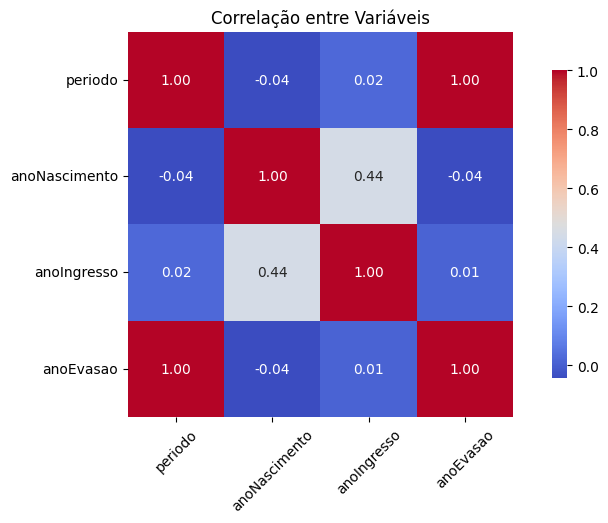

In [21]:
correlacao = data_ufmt.select_dtypes(include=[np.number]).corr(method='pearson')
plt.figure(figsize=(10, 5))
sns.heatmap(correlacao, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlação entre Variáveis')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

## Conclusões
* anoNascimento × anoIngresso	0.44. Correlação moderada positiva — alunos mais jovens tendem a ingressar mais recentemente.
* periodo × anoEvasao. Correlação perfeita.
* Os demais possuem uma correlação baixa/neutra (~0). Não há relação linear clara entre as outras variáveis.

# 2. Análises Descritivas (Panorama Geral dos Dados)  

**1) Taxa de evasão por curso e campus**

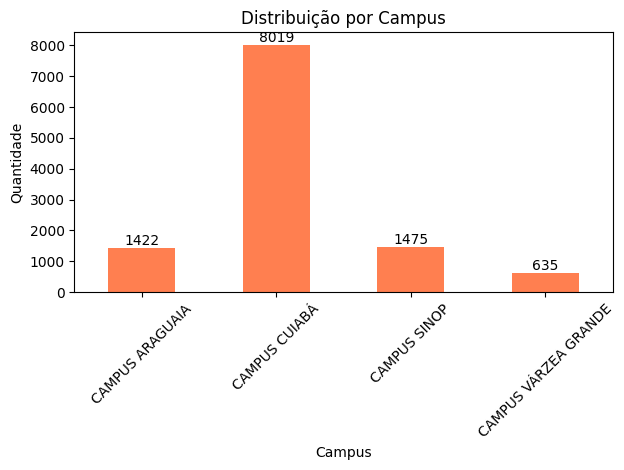

In [22]:
aux = data_ufmt['campus'].value_counts().sort_index().plot(kind='bar', color='coral')

plt.title('Distribuição por Campus')
plt.xlabel('Campus')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)

# Adicionar os valores no topo das barras
for p in aux.patches:
    aux.text(
        p.get_x() + p.get_width() / 2,  # posição x central da barra
        p.get_height(),                 # altura da barra
        int(p.get_height()),           # valor como inteiro
        ha='center', va='bottom'       # alinhamento horizontal e vertical
    )

plt.tight_layout()
plt.show()


## Conclusões do Gráfico: Distribuição por Campus
* A maioria das evasões ocorrerram no Campus Cuiabá (8022), mas ele também é o campus com maior número de alunos matriculados. Então seria necessário saber o número total de alunos em cada campus no período ou uma taxa evasão (número de evadidos dividido pelo total de alunos por campus) para ter uma análise mais precisa.
* O Campus Sinop e Araguaia vem logo em seguida, com números relativamente pertos.


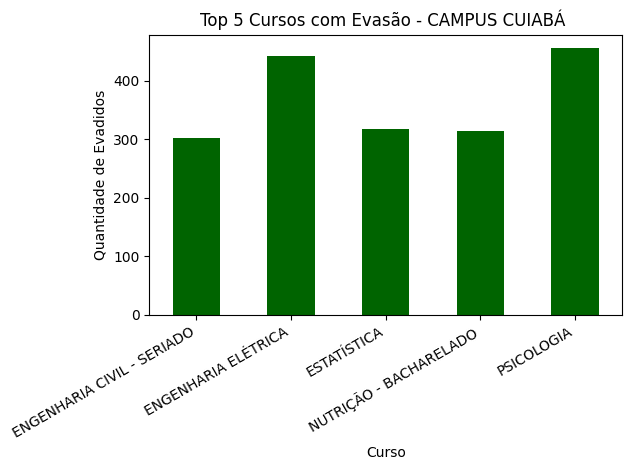

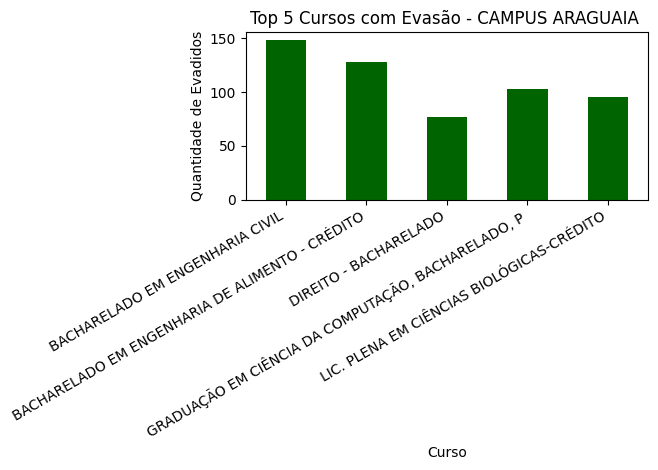

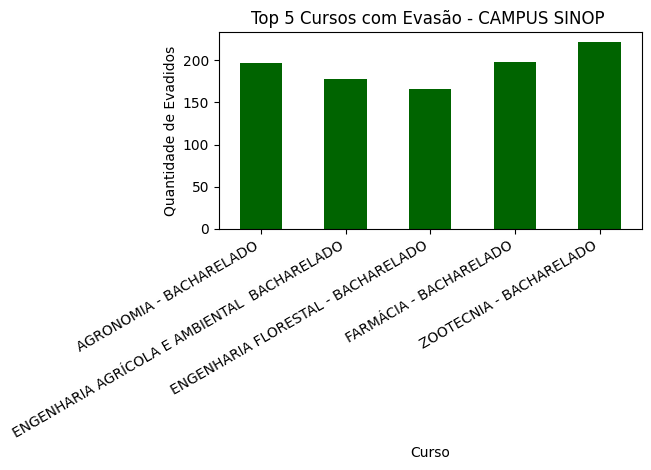

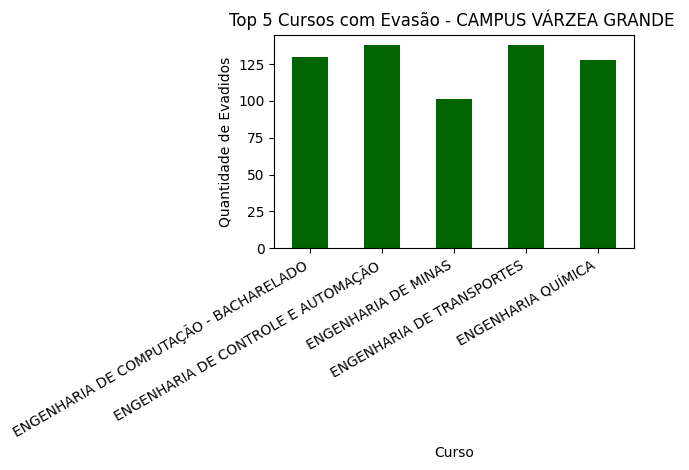

In [23]:
for campus in data_ufmt['campus'].unique():
    dados_campus = data_ufmt[data_ufmt['campus'] == campus]
    top5_cursos = (
        dados_campus['curso']
        .value_counts()
        .head(5)
        .sort_index()
    )

    top5_cursos.plot(kind='bar', color='darkgreen')


    plt.title(
        f"Top 5 Cursos com Evasão - {campus} "
    )

    plt.xlabel('Curso')
    plt.ylabel('Quantidade de Evadidos')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()


## Conclusões dos Gráficos sobre Evasão por Curso e Campus
* Campus Cuiabá:  
    * Psicologia e Eng. Elétrica lideram a evasão no campus com mais de 400 alunos cada.
    * Os 5 cursos com maior número Engenharia Civil – Seriado, Engenharia Elétrica, Estatística e Nutrição – Bacharelado. Os cursos de exatas tendem a terem mais evasões, possivelmente pela falta de uma base matemática de qualidade na educação básica, pressão em geral dos cursos de exatas, dificuldade acadêmica, falta de suporte nos primeiros períodos (como tutoria, reforço) etc.

Psicologia
* Campus Araguaia:  
    * Os 5 cursos com maior número Engenharia Civil – Bacharelado, Engenharia de Alimentos – Bacharelado com Crédito, Direito – Bacharelado, Ciência da Computação – Bacharelad e Ciências Biológicas – Licenciatura Plena com Crédito.
    * Cursos de exatas novamente tendem a terem maiores evasões. O Curso de direito aparece com o menor número de evasões.
* Campus Sinop:  
    * Os 5 cursos com maior número são Zootecnia, Agronomia, Farmácia, Engenharia Agrícula e Ambiental e Engenharia Florestal.
    * Os cursos de engenharia tendem a terem mais alunos evadidos, o mesmo ocorre para os demais campus. Os principais motivos podem ser a alta carga teóricas e matemática, como também, por geralmente esses cursos serem integrais, etc.
* Campus Várzea Grande:  
    * Os 5 cursos com maior número Engenharia de Controle e Automação, Engenharia de Transportes, Engenharia de Computação - Bacharelado, Engenharia Química e Engenharia de Minas. Todos os 5 possuem 100 ou mais alunos que desistiram
    * Dentre os motivos podem ser: alta carga horária e disciplinas com maior grau de dificuldade (como cálculo, física, química), desmotivação por expectativas desalinhadas (muitos alunos entram sem saber bem o que esperar da engenharia), por ser integral etc.


**2) Distribuição por sexo**

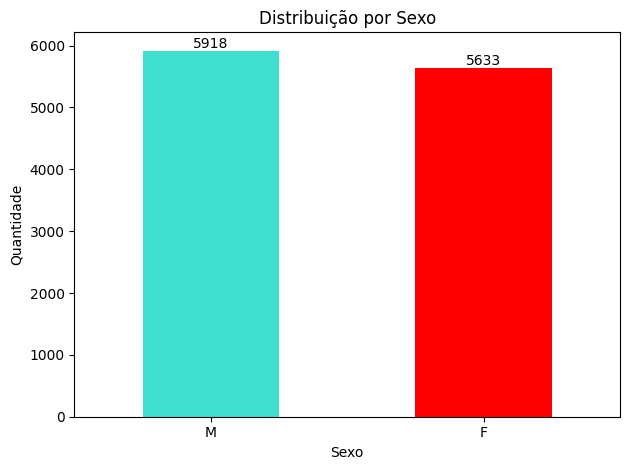

In [24]:
#Distribuição por sexo
aux = data_ufmt['sexo'].value_counts().plot(kind='bar', color=['turquoise', 'red'])
plt.title('Distribuição por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
for p in aux.patches:
    aux.text(
        p.get_x() + p.get_width() / 2,  # posição x central da barra
        p.get_height(),                 # altura da barra
        int(p.get_height()),           # valor como inteiro
        ha='center', va='bottom'       # alinhamento horizontal e vertical
    )
plt.tight_layout()
plt.show()

## Conclusões dos Gráficos sobre Evasão por Estado Civil
* Em relação ao sexo dos estudantes evadidos, a maioria é do sexo masculino (5918), mas não possui uma maioria esmagadora sobre o sexo feminino (5633).
* Não parece ser um fator forte para a desistência dos estudantes.

**3) Distribuição por estado civil**

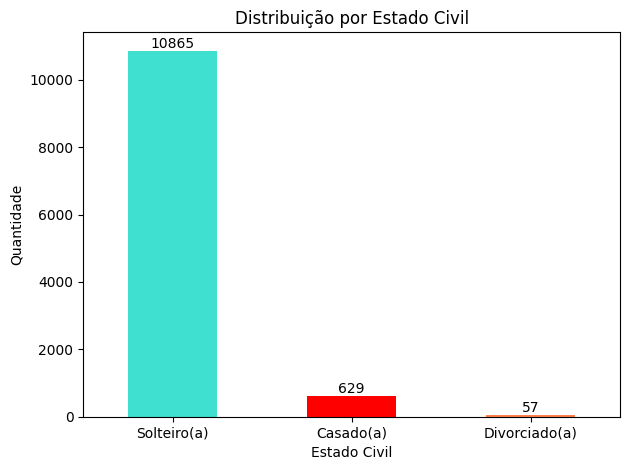

In [25]:
#Distribuição por estado civil
#Ver se há correlação entre estado civil e evasão.
dt = data_ufmt['estadoCivil'].value_counts().plot(kind='bar', color=['turquoise', 'red', 'coral'])
plt.title('Distribuição por Estado Civil')
plt.xlabel('Estado Civil')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
for p in dt.patches:
    dt.text(
        p.get_x() + p.get_width() / 2,  # posição x central da barra
        p.get_height(),                 # altura da barra
        int(p.get_height()),           # valor como inteiro
        ha='center', va='bottom'       # alinhamento horizontal e vertical
    )
plt.tight_layout()
plt.show()

## Conclusões dos Gráficos sobre Evasão por Curso e Campus
* A maioria dos evadidos são solteiros (10865);
* Estudantes casados(os) são 629 dos evadidos e divorciados (as) são apenas 57.
* Pelo gráfico, estudantes solteiros (as) tendem a evadirem mais que os estudantes casados e divorcidados. Esse resultado já era esperado, visto que a maioria dos estudantes são solteiros. 
* Sem uma correlação com a quantidade de estudantes em cada estado civil na mesma época dos que evadiram não há muito o que se analisar, a fim de visualizar percentualmente em qual estado civil tendem a evadir mais. 
* Além disso, muitos estudantes acabaram de sair do ensino médio e estão na primeira faculdade, então já era de se esperar tendessem a evadirem mais. Já que talvez ainda estejam perdidos sobre o querem fazer. 

**4) Idade média na evasão**

In [26]:
data_ufmt['idadeEvasao'] = data_ufmt['anoEvasao'] - data_ufmt['anoNascimento']
idade_media_evasao = round(data_ufmt['idadeEvasao'].mean(), 2)
print(f"Idade média na evasão: {int(idade_media_evasao)}")

Idade média na evasão: 27


# 3. Análises Temporais

**5) Evasão por ano**

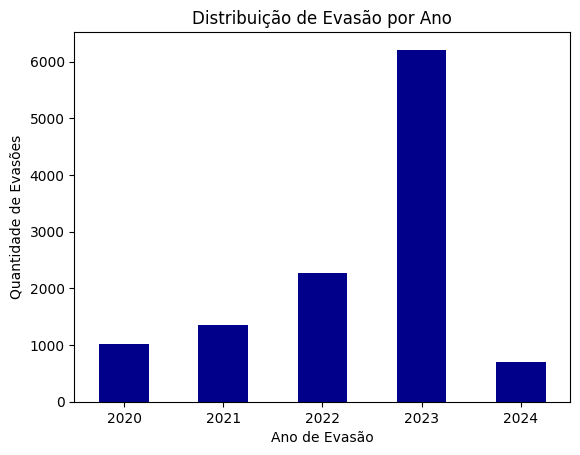

In [27]:
data_ufmt['anoEvasao'].value_counts().sort_index().plot(kind='bar', color='darkblue')
plt.title('Distribuição de Evasão por Ano')
plt.xlabel('Ano de Evasão')
plt.ylabel('Quantidade de Evasões')
plt.xticks(rotation=0)
plt.show()

## Conclusão sobre o que gráfico de evasões anuais
* Entre os anos 2020 e 2023, houve um crescimento gradual e o ano de 2023 foi pico com mais de seis mil evasões. 
* Em 2024, houve uma queda drástica, com menos de 1.000 evasões, quando comparado ao ano anterior.
* No período entre 2020 e 2022 ocorreu a pandemia de Covid-19 e com as aulas presenciais suspensas, esse contexto deve ter levado muitos estudantes a desistirem/abandonadonarem ou mesmo serem jubilados. No ano de 2023, esse contexto possivelmente ainda reflete os impactos acumulados da pandemia, em razão que alguns podem ter sidos alunos anteriores a pandemia ou por outros fatores.

**6) Tempo médio até a evasão**

In [28]:
#Calcular idade na data da evasão: anoEvasao - anoNascimento.
print(f"Tempo médio até a evasão: {(data_ufmt['anoEvasao'] - data_ufmt['anoIngresso']).mean().round(2)}\n")

Tempo médio até a evasão: 3.94



# 4 - Análises geográficas


**7)Evasão por município ou estado (UF)**

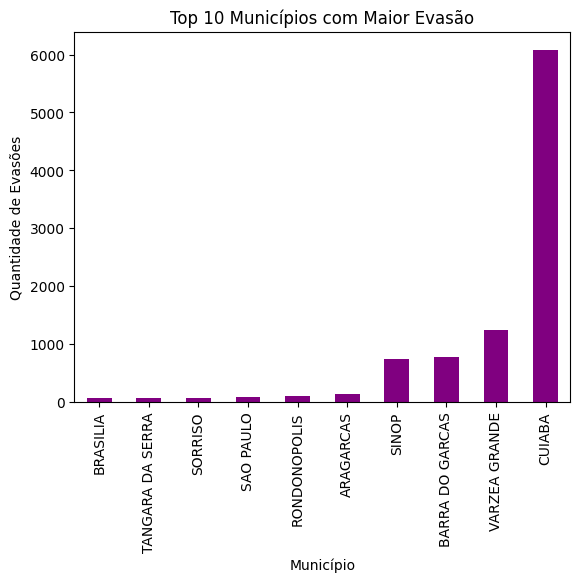

In [29]:
#Evasão por município ou estado (UF)
#Mapeamento dos municípios/UF de origem com maiores índices de evasão.
data_ufmt['municipio'].value_counts().head(10).sort_values().plot(kind='bar', color='purple')
plt.title('Top 10 Municípios com Maior Evasão')
plt.xlabel('Município')
plt.ylabel('Quantidade de Evasões')
plt.xticks(rotation=90)
plt.show()

## Conclusões sobre a evasão por munícipio de origem dos estudantes (Top 10)
* Cuiabá, Várzea Grande, Barra do Garças e Sinop possuem a maior parte das evasões estudantis, as mesmas também são onde estão localizados os campus universários. O que pode significar que os estudantes dessas cidades (Que são o público-alvo) não estão conseguindo se manter dentro da UF, por fatores como incompatibilidade entre o horário dos cursos - principalmente, os cursos integrais - e o trabalho, etc.

**8) Análise de bairros**

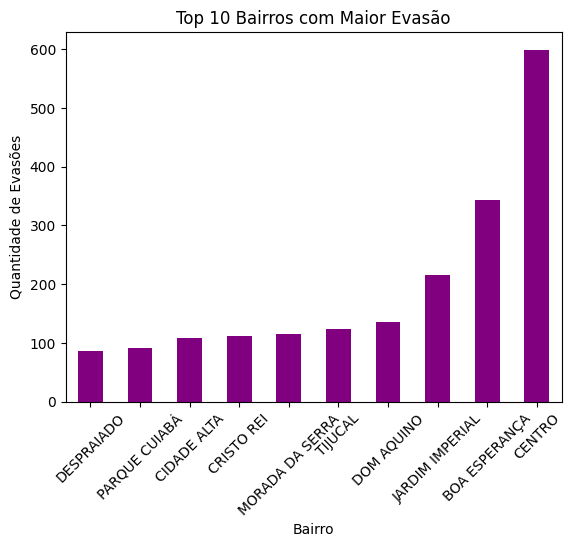

In [30]:
data_ufmt['bairro'] = data_ufmt['bairro'].str.upper().str.strip()
data_ufmt['bairro'].value_counts().head(10).sort_values().plot(kind='bar', color='purple')
plt.title('Top 10 Bairros com Maior Evasão')    
plt.xlabel('Bairro')
plt.ylabel('Quantidade de Evasões')
plt.xticks(rotation=45)
plt.show()

## Conclusões
* A maioria dos estudantes evadidos moravam no centro (600), logo muitos estudantes tendem a morarem nos respectivos centros das cidades onde estudam.
* Boa Esperança e Jardim Imperial seguem em segundo e terceiro lugar, com valores entre 200 e 350 evasões.
* A concentração de evasões em poucos bairros sugere que existem fatores locais relevantes (infraestrutura, mobilidade, custo de vida, segurança).

# 5. Análises por características acadêmicas

**10) Tipo de ocorrência da evasão**

In [31]:
tipos = data_ufmt['ocorrenciaDescricao'].unique().tolist()
print("Tipos de ocorrência: \n")
for t in tipos:
    print(t)


Tipos de ocorrência: 

EXCLUSAO POR DESISTENCIA
EXCLUSÃO POR DESLIGAMENTO - RESOLUÇÃO CONSEPE 68/2014
EXCLUSAO POR TRANSFERENCIA INTERNA
EXCLUIDO POR FALECIMENTO
EXCLUSAO POR TRANSFERENCIA EXTERNA
EXCLUSAO POR TRANSFERENCIA DE REGIME
EXCLUSÃO POR DESLIGAMENTO DE MOBILIDADE ACADÊMICA
EXCLUSAO CONFORME EDITAL SISU - PELA INSTITUIÇÃO
EXCLUSAO SENTENCA JUDICIAL
EXCLUSAO POR TERMINO DE MOBILIDADE ACADEMICA
EXCLUSÃO POR TÉRMINO DE MOBILIDADE INTERNACIONAL
EXCLUSÃO POR MUDANÇA DE CURSO / CANCELAMENTO- ENEM
EXCLUIDO POR SOLICITACAO DA IES
EXCLUÍDO POR DUPLICIDADE DE VÍNCULO - LEI NR. 12.089/09
EXCLUSAO POR TRANSFERENCIA DE CAMPI
EXCLUSAO POR TRANSFERENCIA DE TURNO
EXCLUSÃO DE VÍNCULO ACADÊMICO
EXCLUSAO POR DECISAO DO CONSUNI
EXCLUSÃO POR PROCESSO DISCIPLINAR DISCENTE


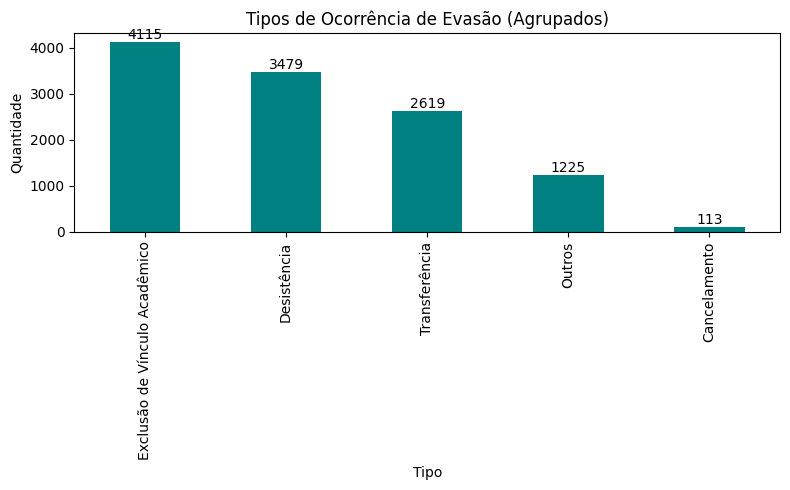

In [32]:
# Função para categorizar cada tipo
def classificar_ocorrencia(desc):
    desc = desc.upper()
    if 'DESISTENCIA' in desc:
        return 'Desistência'
    elif 'TRANSFERENCIA' in desc or 'MOBILIDADE' in desc or 'MUDANCA' in desc:
        return 'Transferência'
    elif 'CANCELAMENTO' in desc or 'DESLIGAMENTO' in desc or 'DECISAO' in desc or 'PROCESSO' in desc:
        return 'Cancelamento'
    elif 'EXCLUSÃO DE VÍNCULO ACADÊMICO' in desc:
        return 'Exclusão de Vínculo Acadêmico'
    else:
        return 'Outros'

# Nova coluna com tipo de ocorrência agrupado
data_ufmt['tipoOcorrencia'] = data_ufmt['ocorrenciaDescricao'].apply(classificar_ocorrencia)

# Conta as categorias
agrupado = data_ufmt['tipoOcorrencia'].value_counts()

# Plota
ax = agrupado.plot(kind='bar', color='teal', figsize=(8,5))
plt.title('Tipos de Ocorrência de Evasão (Agrupados)')
plt.xlabel('Tipo')
plt.ylabel('Quantidade')

# Adiciona valores no topo
for i, v in enumerate(agrupado):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()

## Conclusões finais sobre o motivos das evasões
* Os três principais ocorrências foram por exclusão de vínculo acadêmico (4115), desistência (3479) e transferência (2619). 
* A desistência foi a principal causa explicitamente registrada,  podendo estar relacionado a insatisfação com o curso, dificuldades acadêmicas, pessoais ou financeiras.
* A transferência de curso ou instituição possui uma quantidade considerável de ocorrências.

# 6. Análises cruzadas (possíveis correlações)


**11) Evasão por sexo × curso**

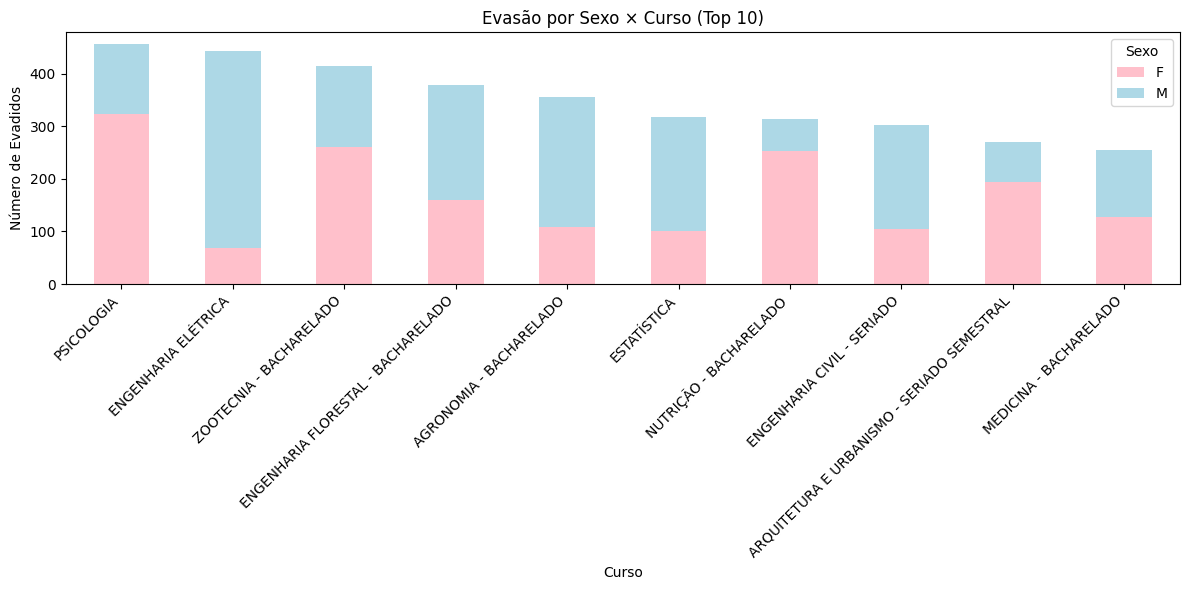

In [33]:
top10 = data_ufmt.groupby(['sexo', 'curso'], observed=False).size().unstack(fill_value=0).sum(axis=0).sort_values(ascending=False).head(10).index

data_ufmt.groupby(['sexo', 'curso'], observed=False).size().unstack(fill_value=0)[top10].T.plot(
    kind='bar', stacked=True, figsize=(12,6), color= ('pink', 'lightblue')
)

plt.title('Evasão por Sexo × Curso (Top 10)')
plt.xlabel('Curso')
plt.ylabel('Número de Evadidos')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sexo')
plt.tight_layout()
plt.show()


## Conclusões sobre evasão por Sexo × Curso (Top 10)
* Nos cursos 10 cursos com mais evasões, a grande maioria das evasões são de estudantes do sexo masculino.
* Nos cursos com maioria das evasões sendo do sexo feminino, 2 deles são geralmente curso majoritariamente realizados por mulheres. Então, já era esperado esse resultado. Talvez com uma correlação entre porcentagem de estudantes matriculados de cada sexo e dos evadidos mostre de maneira melhor se há uma forte relação entre sexo dos discentes e a evasão.

**12) Evasão por campus × tempo até evasão**

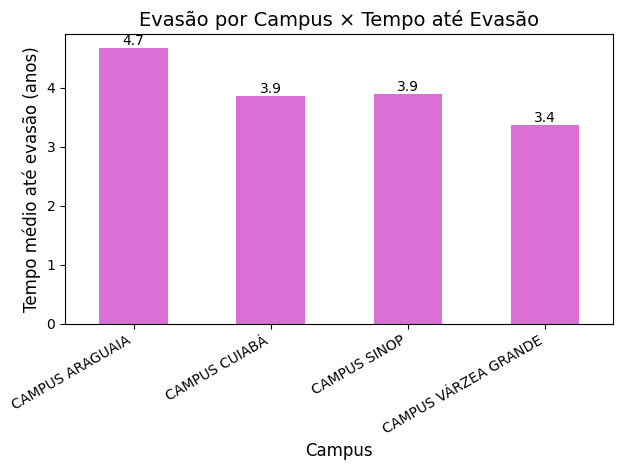

In [34]:
# calcula o tempo de permanência
data_ufmt['tempoPermanencia'] = data_ufmt['anoEvasao'] - data_ufmt['anoIngresso']

# agrupa por campus e calcula média
tempo_medio = (
    data_ufmt.groupby('campus', observed=False)['tempoPermanencia']
    .mean()
    .sort_index(ascending=True)
)

# plota o gráfico
aux = tempo_medio.plot(kind='bar', color='orchid')
plt.title('Evasão por Campus × Tempo até Evasão', fontsize=14)
plt.xlabel('Campus', fontsize=12)
plt.ylabel('Tempo médio até evasão (anos)', fontsize=12)
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(tempo_medio):
    aux.text(i, v, f"{v:.1f}", ha='center', va='bottom')
plt.tight_layout()
plt.show()


## Conclusões dos Gráficos sobre Evasão por Curso e Campus
* Os estudantes do campus Araguaia tendem a permanecerem mais tempo até evadirem (4 anos ou mais).
* O campus Sinop e Cuiabá vem logo atrás com ambos tendo entre 3 e 4 anos. Os estudantes do campus Vázea Grande, tendem a permanecerem menos tempo até trancarem.

**13) Estado civil × tempo de permanência**

/tmp/ipykernel_96922/3979192780.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_ufmt.groupby('estadoCivil')['tempoPermanencia'].mean().sort_values().plot(kind='bar', color='coral')


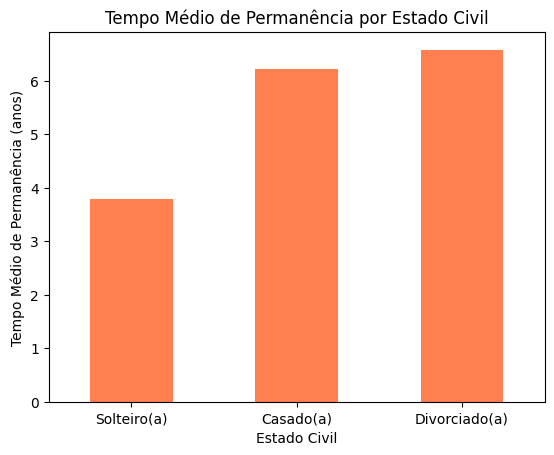

In [35]:
data_ufmt.groupby('estadoCivil')['tempoPermanencia'].mean().sort_values().plot(kind='bar', color='coral')
plt.title('Tempo Médio de Permanência por Estado Civil')
plt.xlabel('Estado Civil')
plt.ylabel('Tempo Médio de Permanência (anos)')
plt.xticks(rotation=0)
plt.show()

## Conclusões dos Gráficos sobre Evasão por Curso e Campus
* Estudantes casados e divorciados tendem a permanecerem mais tempo na UFMT (5 anos ou mais).
* O que leva a pensar se a dinâmica da universidade (principalmente em cursos integrais) podem estar levando esses estudantes a permanecerem muito mais tempo do que o tempo permitido e acabarem jubilados ou fazerem eles optarem por trancar o curso. Visto que geralmente, eles trabalham.

**14) Município × idade de evasão**

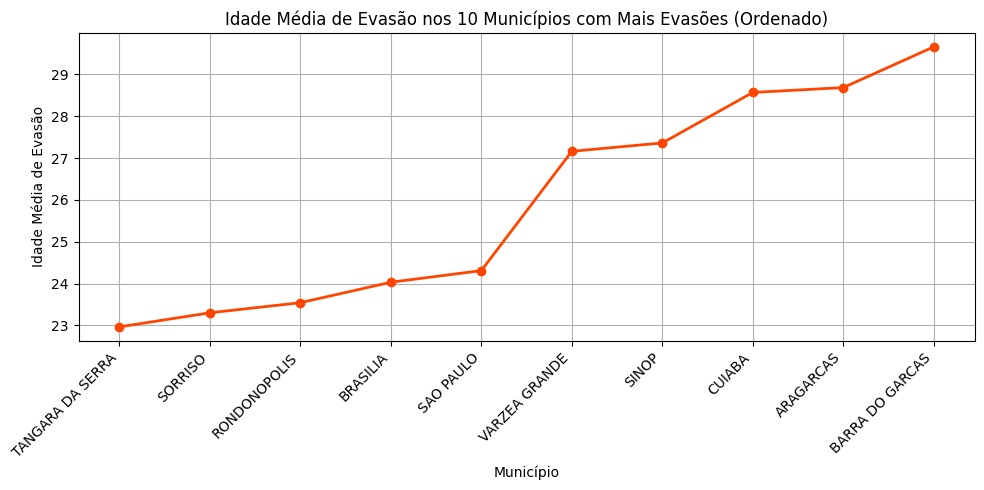

In [36]:
# Top 10 municípios com mais evasões
top_municipios = data_ufmt['municipio'].value_counts().nlargest(10).index
df_top10 = data_ufmt[data_ufmt['municipio'].isin(top_municipios)]

# Calcula idade média por município e ordena do menor para o maior
resumo = df_top10.groupby('municipio', observed=False)['idadeEvasao'].mean().loc[top_municipios]
resumo = resumo.sort_values()  # <-- esta linha é o que faltava

# Gráfico de linha
plt.figure(figsize=(10, 5))
plt.plot(resumo.index, resumo.values, color='orangered', marker='o', linewidth=2)

plt.title('Idade Média de Evasão nos 10 Municípios com Mais Evasões (Ordenado)')
plt.ylabel('Idade Média de Evasão')
plt.xlabel('Município')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()


## Conclusões
* A idade média de evasão varia de aproximadamente 23 até 29 anos.
* Tangará da Serra (23 anos) possui a menor média de idade dos estudantes evadidos. Já Barra do Garças possui a maior (Mais ou menos 29 anos).
* Evasão mais tardia pode estar ligada a cursos mais longos (ex: medicina), estudantes que tentaram conciliar estudo e trabalho por mais tempo, trancamentos temporários dos cursos etc.

**15) Evasão por curso × ano de ingresso**

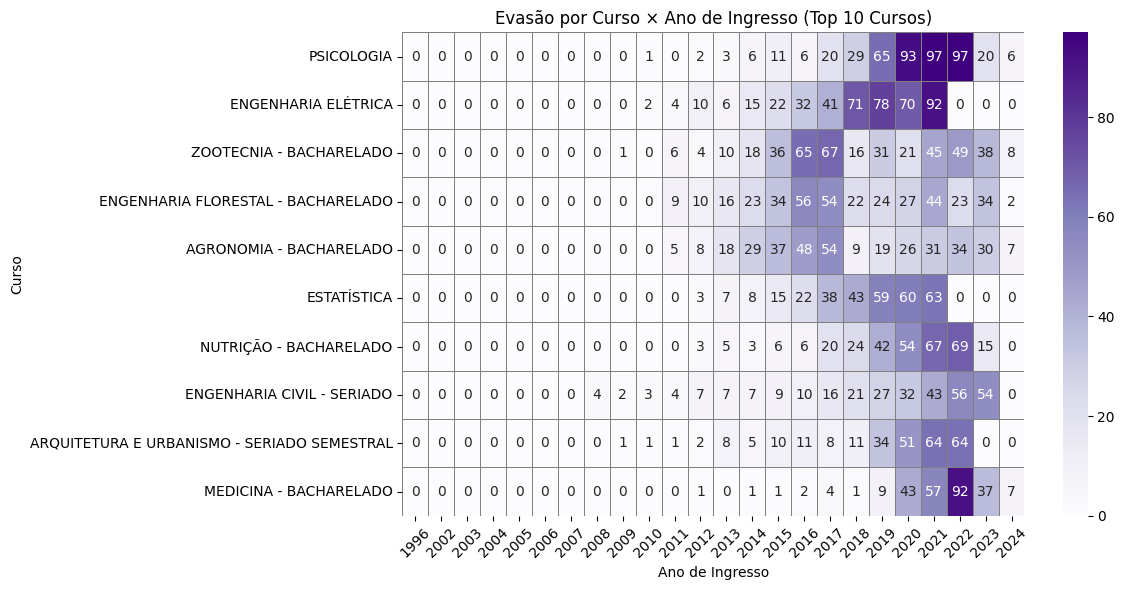

In [37]:
# Gera tabela cruzada: quantidade de evasões por curso e ano de ingresso
tabela = pd.crosstab(data_ufmt['curso'], data_ufmt['anoIngresso'])

# Seleciona os 10 cursos com mais evasões no total
top_cursos = tabela.sum(axis=1).nlargest(10).index
tabela_top10 = tabela.loc[top_cursos]

# Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(tabela_top10, annot=True, fmt='d', cmap='Purples', linewidths=0.5, linecolor='gray')
plt.title('Evasão por Curso × Ano de Ingresso (Top 10 Cursos)')
plt.xlabel('Ano de Ingresso')
plt.ylabel('Curso')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Conclusões
*  Padrões Observados:
    * A maior parte da evasão concentra-se em ingressantes de 2016 a 2021, com destaque para:
        * Psicologia (2019–2021): picos de 93 a 97 evadidos por ano.
        * Eng. Elétrica (2018–2020): até 92 evadidos.
        * Zootecnia e Nutrição (2016–2020): crescimento expressivo.
        * Medicina (2021): também surpreende com 92 evadidos.

    * Evasão tende a cair nos ingressantes mais recentes (2022–2024), o que pode indicar: Tempo insuficiente para evasão ocorrer, estudantes voltando ao ensino superior após a pandemia etc